In [19]:
import os
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [20]:
Model_Config = "MobileNetSSD_deploy.prototxt"
Model_Weights = "MobileNetSSD_deploy.caffemodel"
Classes = ["background", "aeroplane", "bicycle", "bird", "boat", "bottle", "bus",
           "car", "cat", "chair", "cow", "dinigtable", "dog", "horse", "motorbike",
           "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"]

In [21]:
net = cv2.dnn.readNetFromCaffe(Model_Config, Model_Weights)

In [28]:
def detect_person_in_video(video_path):
  cap = cv2.VideoCapture(video_path)

  while True:
    ret, frame = cap.read()
    if not ret:
      print("Fim do vídeo ou erro de leitura.")
      cap.release()
      return "Nenhuma pessoa detectada no video"

    (h,w) = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 0.007843, (300, 300), 127.5)
    net.setInput(blob)
    detections = net.forward()

    person_detected_in_this_frame = False
    for i in range(detections.shape[2]):
      confidence = detections[0, 0, i, 2]
      # Lowered confidence threshold to 0.7 for better detection
      if confidence > 0.7:
        idx = int(detections[0, 0, i, 1])
        if Classes[idx] == "person":
          person_detected_in_this_frame = True

          box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
          (startX, startY, endX, endY) = box.astype("int")

          label = f"{Classes[idx]}: {confidence * 100:.2f}"
          cv2.rectangle(frame, (startX, startY), (endX, endY), (0,255,0),2)
          cv2.putText(frame, label, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    if person_detected_in_this_frame:
      print("Pessoa detectada no video. Exibindo o frame:")
      cv2_imshow(frame)
      cap.release()
      return "Pessoa detectada no video"

  # This part should ideally be unreachable if the video processing terminates correctly
  cap.release()
  return "Nenhuma pessoa detectada no video"

Pessoa detectada no video. Exibindo o frame:


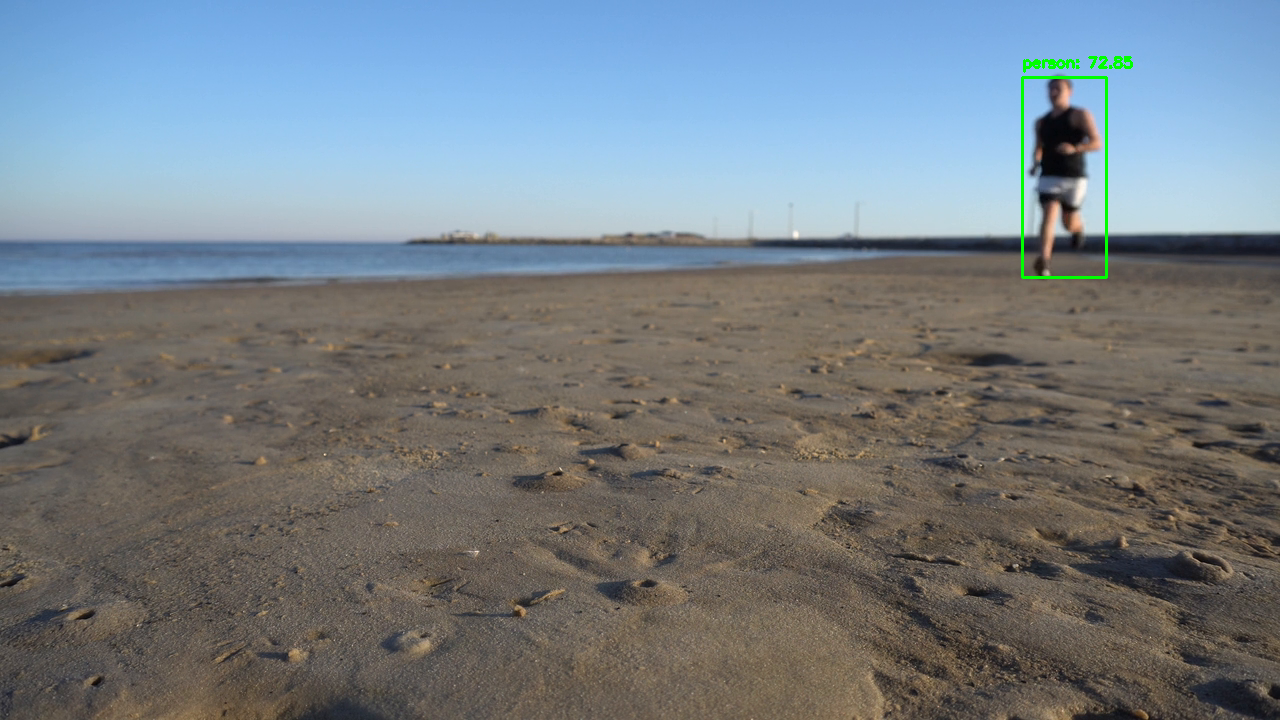

Pessoa detectada no video


In [29]:
print(detect_person_in_video("people.mp4"))